In [1]:
import sys
sys.path.append("..")
from models.MIL import RadiomicsMIL
from dataloaders.deep_dataloaders import get_dataloaders_deep_learning
from utils import read_yaml_file, test_model, compute_classification_metrics, save_json, test_model_graph
import torch
import numpy as np
import os
from glob import glob
from pathlib import Path

In [2]:
import argparse 
from models.deep_sets import RadiomicsDeepSets
from models.transformer import RadiomicsTransformer
from models.MIL import RadiomicsMIL
from models.graph import RadiomicsGraph
from models.set_transformer import RadiomicsSetTransformer
from models.classical_ml import get_ml_models
from dataloaders.deep_dataloaders import get_dataloaders_deep_learning, get_center2_as_test_loader
from dataloaders.graph_dataloader import get_dataloaders_graph, get_center2_as_test_loader_graph
from dataloaders.ml_dataloaders import get_dataloaders_ml, get_classical_test_loader_center2
from utils import read_yaml_file, test_model, compute_classification_metrics, save_json, test_model_graph
from pathlib import Path

def model_generator(model_name: str):
    if model_name == "transformer":
        return RadiomicsTransformer
    elif model_name == "deep_sets":
        return RadiomicsDeepSets
    elif model_name == "mil":
        return RadiomicsMIL
    elif model_name == "graph":
        return RadiomicsGraph
    elif model_name == "set_transformer":
        return RadiomicsSetTransformer
    else:
        raise ValueError(f"Model {model_name} not found in model zoo.")

def data_function_generator_dl(args):
    if args.model_name in ["transformer", "deep_sets", "mil", "set_transformer"]:
        return get_dataloaders_deep_learning, get_center2_as_test_loader, test_model
    elif args.model_name == "graph":
        return get_dataloaders_graph, get_center2_as_test_loader_graph, test_model_graph
    else:
        raise ValueError(f"Model {args.model_name} not found in data function generator.")


def get_trained_model(args, fold_index: int):
    config_base_dir = '../configs'
    model_configs = read_yaml_file(Path(config_base_dir) / f"{args.model_name}.yaml")
    args.batch_size = model_configs['batch_size']
    print(args.use_coords, args.use_demographic)
    # get dataloaders
    get_data_loaders, get_center2_loader, test_model_func = data_function_generator_dl(args)
    train_loader, val_loader, test_loader = get_dataloaders_deep_learning(args, fold_index=fold_index)
    center2_loader = get_center2_loader(args)
    # define input dimension
    sample_batch = next(iter(train_loader))
    if args.model_name == "graph":
        input_dim = sample_batch.num_node_features
    else:
        input_dim = sample_batch['features'].shape[-1]
    print(f"Input dimension: {input_dim}")
    MODEL = model_generator(args.model_name)
    model = MODEL.load_from_checkpoint(args.best_model_path, 
                            input_dim=input_dim,
                            config=model_configs)   
    return model, test_loader    

class ARGS:
    def __init__(self, best_model_path: str, use_coords: bool, use_demographic: bool):
        self.data_root = "/home/reza/Documents/Reza_projects/08_drarabi_lymphnodes/new_dataset"
        self.model_name = "mil"
        self.use_coords = use_coords
        self.use_demographic = use_demographic
        self.batch_size = 32
        self.best_model_path = best_model_path




In [29]:
def get_attention_preds(model, test_loader, node_percentage=None):
    all_preds = []
    all_probs = []
    all_labels = []
    attention_masks = []
    model.eval()
    with torch.no_grad():
        for batch in test_loader:
            x, y, mask = batch['features'], batch['labels'], batch.get('pad_mask', None)
            if node_percentage is not None:
                num_nodes = x.shape[1]
                k = max(1, int(num_nodes * node_percentage))
                topk_values, topk_indices = torch.topk(torch.rand(num_nodes), k)
                x = x[:, topk_indices, :]
                if mask is not None:
                    mask = mask[:, topk_indices]
            logits, attention = model.get_pred_and_attention(x.to(model.device), mask.to(model.device) if mask is not None else None)
            probs = torch.softmax(logits, dim=1)[:, 1]
            preds = torch.argmax(logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(y.cpu().numpy())
            attention_masks.extend(attention.cpu().numpy())
    return np.array(all_labels), np.array(all_preds), np.array(all_probs), attention_masks

In [24]:
def node_attention_calculation(attention_masks, test_loader):
    normalized_attention_masks = []
    for patient_id in range(len(attention_masks)):
        nodes_importance = attention_masks[patient_id]
        nodes_importance = nodes_importance[nodes_importance > 0]
        normalized_attention_masks.extend(nodes_importance * len(nodes_importance))
        nodes_coordinates = test_loader.dataset.aggregated_data[patient_id]['nodes_coordinates']
        print("node importances for patient ", patient_id)
        print(f"len nodes importance: {len(nodes_importance)}, len total nodes: {len(nodes_coordinates)}")
        print(nodes_importance)
        print("nodes coordinates:")
        print(nodes_coordinates)
        print("="*20)
    return normalized_attention_masks

In [25]:
fold_index = 4

use_coords = False
use_demographic = False
best_model_path = f"/home/reza/Documents/Reza_projects/08_drarabi_lymphnodes/cleaned_code/Results/mil_radiomics/fold_{fold_index}/checkpoints/best.ckpt"

args = ARGS(best_model_path=best_model_path, use_coords=use_coords, use_demographic=use_demographic)

model, test_loader = get_trained_model(args, fold_index=fold_index)
y_true, y_pred, y_prob = test_model(model, test_loader)
print(compute_classification_metrics('mil', y_true, y_pred, y_prob))
y_true, y_pred, y_prob, attention_masks = get_attention_preds(model, test_loader)
radiomics_normalized_attention_masks = node_attention_calculation(attention_masks, test_loader)

False False
Train size: 102, Val size: 19, Test size: 30
Razavi Test size: 80
Input dimension: 107
{'model': 'mil', 'accuracy': 0.6206896551724138, 'precision': 0.6363636363636364, 'recall': 0.8235294117647058, 'specificity': np.float64(0.3333333333333333), 'f1_score': 0.717948717948718, 'roc_auc': 0.6519607843137255}
torch.Size([1, 49, 107]) torch.Size([1]) tensor([[False, False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False]])
torch.Size([1, 8, 107]) torch.Size([1]) tensor([[False, False, False, False, False, False, False, False]])
torch.Size([1, 1, 107]) torch.Size([1]) tensor([[False]])
torch.Size([1, 2, 107]) torch.Size([1]) tensor([[False, False]])
torch.Size([1, 4, 1

In [43]:
use_coords = True
use_demographic = True
best_model_path = f"/home/reza/Documents/Reza_projects/08_drarabi_lymphnodes/cleaned_code/Results/mil_coords_demographic_radiomics/fold_{fold_index}/checkpoints/best.ckpt"


args = ARGS(best_model_path=best_model_path, use_coords=use_coords, use_demographic=use_demographic)

model, test_loader = get_trained_model(args, fold_index=fold_index)
y_true, y_pred, y_prob = test_model(model, test_loader)
print(compute_classification_metrics('mil', y_true, y_pred, y_prob))
y_true, y_pred, y_prob, attention_masks = get_attention_preds(model, test_loader)
coords_demographic_radiomics_normalized_attention_masks = node_attention_calculation(attention_masks, test_loader)

True True
Train size: 102, Val size: 19, Test size: 30
Razavi Test size: 80
Input dimension: 112
{'model': 'mil', 'accuracy': 0.7586206896551724, 'precision': 0.7777777777777778, 'recall': 0.8235294117647058, 'specificity': np.float64(0.6666666666666666), 'f1_score': 0.8, 'roc_auc': 0.8529411764705882}
node importances for patient  0
len nodes importance: 49, len total nodes: 49
[0.01911443 0.02106661 0.02055903 0.02055887 0.02105811 0.01945723
 0.02211717 0.01865914 0.02121127 0.02148785 0.0211218  0.02088307
 0.02073465 0.02150941 0.02070863 0.01858418 0.02041411 0.02130175
 0.02155151 0.01883115 0.0192061  0.02019246 0.02100701 0.01989075
 0.02073443 0.02007365 0.02035652 0.02331569 0.02047253 0.02108408
 0.01798738 0.02066242 0.01749402 0.02145845 0.02328239 0.02170692
 0.02196436 0.01957176 0.02182424 0.02043193 0.02079302 0.01892305
 0.02065173 0.01945376 0.01872477 0.02109428 0.0205876  0.01804261
 0.01808221]
nodes coordinates:
['(99.22619047619048, 130.89285714285714, 280.0476

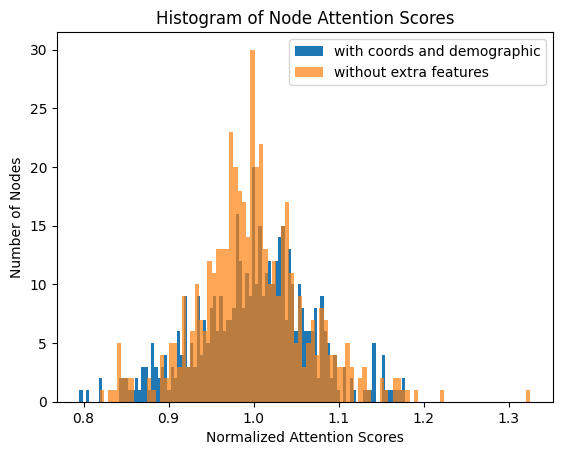

In [44]:
# with coords and demographic
import matplotlib.pyplot as plt
_ = plt.hist(coords_demographic_radiomics_normalized_attention_masks, bins=100, label='with coords and demographic')
_ = plt.hist(radiomics_normalized_attention_masks, bins=100, alpha=0.7, label='without extra features')
plt.legend()
plt.xlabel("Normalized Attention Scores")
plt.ylabel("Number of Nodes")
plt.title("Histogram of Node Attention Scores")
plt.show()


In [42]:
import SimpleITK as sitk

def read_sitk_image(file_path):
    img = sitk.ReadImage(file_path)
    return img

def sitk_image_to_array(sitk_image):
    array = sitk.GetArrayFromImage(sitk_image)
    return array

def array_to_sitk_image(array, reference_sitk_image):
    sitk_image = sitk.GetImageFromArray(array)
    sitk_image.CopyInformation(reference_sitk_image)
    return sitk_image

In [55]:
patient_id = 23

nodes_importance = attention_masks[patient_id]
nodes_coordinates = test_loader.dataset.aggregated_data[patient_id]['nodes_coordinates']
print("node importances for patient ", patient_id)
print(f"len nodes importance: {len(nodes_importance[nodes_importance>0])}, len total nodes: {len(nodes_coordinates)}")
print(nodes_importance[nodes_importance>0])
print("nodes coordinates:")
print(nodes_coordinates)


node importances for patient  23
len nodes importance: 12, len total nodes: 12
[0.08948013 0.09031311 0.09047768 0.08774967 0.10980751 0.07049412
 0.0786042  0.08069063 0.08900055 0.07224417 0.07233895 0.06879935]
nodes coordinates:
['(104.82025677603424, 128.94293865905848, 245.29671897289586)', '(121.09655172413792, 129.03275862068966, 252.4948275862069)', '(87.69568921451696, 118.95723291872551, 238.914636224229)', '(129.42187860604662, 119.6912070159243, 240.28456035079623)', '(92.36720554272517, 133.60739030023095, 236.78983833718246)', '(122.99860178970917, 118.7841163310962, 226.6006711409396)', '(88.18106995884774, 117.14814814814815, 219.79835390946502)', '(91.37666174298376, 119.57311669128508, 225.48818316100443)', '(111.90310559006211, 111.09937888198758, 218.12670807453415)', '(124.03418803418803, 116.76068376068376, 214.89743589743588)', '(114.42708333333333, 106.30208333333333, 213.04166666666666)', '(120.06666666666666, 108.60606060606061, 214.3212121212121)']


In [56]:
pid = test_loader.dataset.aggregated_data[patient_id]['ID']
data_path = Path(data_root) / "Masih-SUV" / f"{pid}" 
img_path = glob(str(data_path / "*_prep_img.nii.gz"))
seg_path = glob(str(data_path / "*_prep_seg.nii.gz"))
img_sitk = read_sitk_image(img_path[0])
seg_sitk = read_sitk_image(seg_path[0])
img_array = sitk_image_to_array(img_sitk)
seg_array = sitk_image_to_array(seg_sitk)
print(f"image shape: {img_array.shape}")
print(f"segmentation shape: {seg_array.shape}")

image shape: (299, 224, 224)
segmentation shape: (299, 224, 224)


In [57]:
import ast
weights_mask = np.zeros_like(seg_array)
for node_center, importance in zip(nodes_coordinates, nodes_importance):
    node_center = np.array(ast.literal_eval(node_center)).astype(int)[::-1]  # reverse to z,y,x
    print(f"node center: {node_center}, intensity value: {seg_array[node_center[0], node_center[1], node_center[2]]}")
    label = seg_array[node_center[0], node_center[1], node_center[2]]
    weights_mask[seg_array == label] += importance
weights_sitk = array_to_sitk_image(weights_mask, seg_sitk)
save_dir = Path("mil_attention_visualization") / f"patient_{patient_id}"
if not save_dir.exists():
    os.makedirs(save_dir)
sitk.WriteImage(weights_sitk, save_dir / "patient_nodes_attention_weights.nii.gz")
sitk.WriteImage(seg_sitk, save_dir / "patient_nodes_segmentation.nii.gz")
sitk.WriteImage(img_sitk, save_dir / "patient_image.nii.gz")

node center: [245 128 104], intensity value: 1.0
node center: [252 129 121], intensity value: 2.0
node center: [238 118  87], intensity value: 3.0
node center: [240 119 129], intensity value: 4.0
node center: [236 133  92], intensity value: 5.0
node center: [226 118 122], intensity value: 6.0
node center: [219 117  88], intensity value: 7.0
node center: [225 119  91], intensity value: 8.0
node center: [218 111 111], intensity value: 9.0
node center: [214 116 124], intensity value: 11.0
node center: [213 106 114], intensity value: 12.0
node center: [214 108 120], intensity value: 16.0


# Node number effect in final decision

In [31]:
def test_model(model, test_loader, node_percentage=None):
        model.eval()
        all_preds = []
        all_probs = []
        all_labels = []
        try:
            device = model.device
        except:
             device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        with torch.no_grad():
            for batch in test_loader:
                x, y, mask = batch['features'], batch['labels'], batch.get('pad_mask', None)
                if node_percentage is not None:
                    num_nodes = x.shape[1]
                    k = max(1, int(num_nodes * node_percentage))
                    topk_values, topk_indices = torch.topk(torch.rand(num_nodes), k)
                    x = x[:, topk_indices, :]
                    if mask is not None:
                        mask = mask[:, topk_indices]
                logits = model(x.to(device), mask.to(device) if mask is not None else None)

                probs = torch.softmax(logits, dim=1)[:, 1]
                preds = torch.argmax(logits, dim=1)
                all_preds.extend(preds.cpu().numpy())
                all_probs.extend(probs.cpu().numpy())
                all_labels.extend(y.cpu().numpy())
        return np.array(all_labels), np.array(all_preds), np.array(all_probs)

True True
Train size: 102, Val size: 19, Test size: 30
Razavi Test size: 80
Input dimension: 112
{0.2: [{'model': 'mil', 'accuracy': 0.6551724137931034, 'precision': 0.6842105263157895, 'recall': 0.7647058823529411, 'specificity': np.float64(0.5), 'f1_score': 0.7222222222222222, 'roc_auc': 0.823529411764706}, {'model': 'mil', 'accuracy': 0.7241379310344828, 'precision': 0.8, 'recall': 0.7058823529411765, 'specificity': np.float64(0.75), 'f1_score': 0.75, 'roc_auc': 0.8284313725490197}, {'model': 'mil', 'accuracy': 0.6896551724137931, 'precision': 0.7222222222222222, 'recall': 0.7647058823529411, 'specificity': np.float64(0.5833333333333334), 'f1_score': 0.7428571428571429, 'roc_auc': 0.8382352941176471}, {'model': 'mil', 'accuracy': 0.6896551724137931, 'precision': 0.75, 'recall': 0.7058823529411765, 'specificity': np.float64(0.6666666666666666), 'f1_score': 0.7272727272727273, 'roc_auc': 0.8088235294117647}, {'model': 'mil', 'accuracy': 0.6896551724137931, 'precision': 0.75, 'recall':

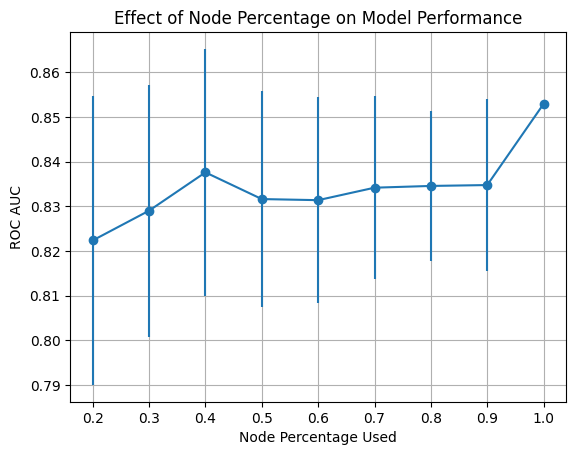

In [ ]:
use_coords = True
use_demographic = True
best_model_path = f"/home/reza/Documents/Reza_projects/08_drarabi_lymphnodes/cleaned_code/Results/mil_coords_demographic_radiomics/fold_{fold_index}/checkpoints/best.ckpt"


args = ARGS(best_model_path=best_model_path, use_coords=use_coords, use_demographic=use_demographic)

model, test_loader = get_trained_model(args, fold_index=fold_index)
sweep_results = {}
for node_percentage in [i/10 for i in range(2, 11)]:
    repeats_results = []
    for repeats in range(100):
        y_true, y_pred, y_prob = test_model(model, test_loader, node_percentage=node_percentage)
        metrics_dict = compute_classification_metrics('mil', y_true, y_pred, y_prob)
        repeats_results.append(metrics_dict)
    sweep_results[node_percentage] = repeats_results


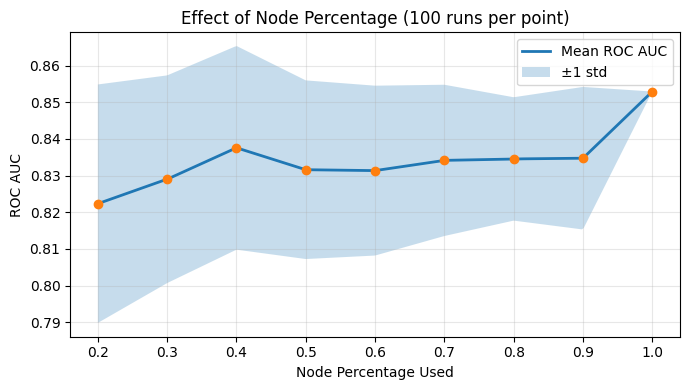

In [65]:
import numpy as np
import matplotlib.pyplot as plt

percentages = np.array(sorted(sweep_results.keys()))  # e.g. [0.2, ..., 1.0]

# shape: (num_percentages, 100)
metric_runs = np.array([
    [r["roc_auc"] for r in sweep_results[p]]
    for p in percentages
], dtype=float)

mean = metric_runs.mean(axis=1)
std  = metric_runs.std(axis=1, ddof=1)   # sample std (recommended)

x_fine = np.linspace(percentages.min(), percentages.max(), 300)

mean_fine = np.interp(x_fine, percentages, mean)
std_fine  = np.interp(x_fine, percentages, std)


plt.figure(figsize=(7, 4))

plt.plot(x_fine, mean_fine, linewidth=2, label="Mean ROC AUC")
plt.fill_between(
    x_fine,
    mean_fine - std_fine,
    mean_fine + std_fine,
    alpha=0.25,
    label="±1 std"
)

# Optional: show actual mean points
plt.scatter(percentages, mean, zorder=3)

plt.xlabel("Node Percentage Used")
plt.ylabel("ROC AUC")
plt.title("Effect of Node Percentage (100 runs per point)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
